# 2. Exploratory Data Analysis
## Southeast Asian Daily Weather Patterns (2000–2024)
### NOAA GHCN-Daily · 10 Countries · 218 Stations · 1,011,376 Station-Days

**Research Questions:**
1. How have daily temperature extremes (TMAX, TMIN) changed across SE Asian stations from 2000 to 2024?
2. Are extreme precipitation events (daily rainfall > 95th percentile) becoming more frequent?
3. How do climate patterns vary seasonally by country?
4. How does Vietnam compare to neighbouring countries?

**Analyses in this notebook:**
- Analysis 1: Long-Term Temperature Trends (yearly avg TMAX/TMIN per country, trendlines, decade boxplots)
- Analysis 2: Precipitation Pattern Changes (yearly totals, rainy day counts, intensity)
- Analysis 3: Seasonality Heatmaps (Month × Year for TMAX and PRCP)
- Analysis 4: Station Coverage Analysis (geospatial map, data availability over time)

In [64]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, avg, sum as spark_sum, count, when,
    max as spark_max, min as spark_min,
)
import pyspark.sql.functions as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

OUTPUT_DIR = '../output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

spark = SparkSession.builder \
    .appName('GHCN-SEA-EDA') \
    .config('spark.driver.memory', '8g') \
    .config('spark.sql.adaptive.enabled', 'true') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')

df = spark.read.parquet('../data/processed/sea_weather_2000_2024.parquet')
df.cache()

stats = df.agg(
    count('*').alias('total'),
    F.countDistinct('STATION_ID').alias('stations'),
    F.countDistinct('COUNTRY').alias('countries'),
).collect()[0]
print(f"Loaded: {stats.total:,} rows | {stats.stations} stations | {stats.countries} countries")
print(f"Columns: {df.columns}")
df.select('STATION_ID','DATE','YEAR','MONTH','TMAX','TMIN','PRCP','TEMP_RANGE','COUNTRY','LATITUDE','LONGITUDE').show(3)

Loaded: 1,011,376 rows | 218 stations | 10 countries
Columns: ['STATION_ID', 'DATE', 'TMAX', 'TMIN', 'PRCP', 'YEAR', 'MONTH', 'DAY_OF_YEAR', 'TEMP_RANGE', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'COUNTRY', 'COUNTRY_CODE', 'NAME']
+-----------+----------+----+-----+----+----+----+-----------------+---------+--------+---------+
| STATION_ID|      DATE|YEAR|MONTH|TMAX|TMIN|PRCP|       TEMP_RANGE|  COUNTRY|LATITUDE|LONGITUDE|
+-----------+----------+----+-----+----+----+----+-----------------+---------+--------+---------+
|ID000096163|2000-01-01|2000|    1|30.8|23.6|NULL|7.199999999999999|Indonesia|  -0.883|   100.35|
|IDM00097760|2000-01-02|2000|    1|31.2|25.2|NULL|              6.0|Indonesia|  -3.645|  133.696|
|TH000048375|2000-01-03|2000|    1|33.0|16.5| 0.0|             16.5| Thailand|  16.667|    98.55|
+-----------+----------+----+-----+----+----+----+-----------------+---------+--------+---------+
only showing top 3 rows


In [65]:
print("DATASET SUMMARY")

print("\nObservations per country:")
df.groupBy('COUNTRY').agg(
    count('*').alias('rows'),
    F.countDistinct('STATION_ID').alias('stations'),
    spark_min('YEAR').alias('from_year'),
    spark_max('YEAR').alias('to_year'),
).orderBy('rows', ascending=False).show()

print("Descriptive statistics (TMAX, TMIN, PRCP, TEMP_RANGE):")
df.select('TMAX','TMIN','PRCP','TEMP_RANGE').describe().show()

DATASET SUMMARY

Observations per country:
+-----------+------+--------+---------+-------+
|    COUNTRY|  rows|stations|from_year|to_year|
+-----------+------+--------+---------+-------+
|  Indonesia|490634|     103|     2000|   2024|
|   Thailand|256662|      45|     2000|   2024|
|Philippines|109166|      23|     2000|   2024|
|    Vietnam| 55192|      16|     2000|   2024|
|   Malaysia| 47226|      16|     2000|   2024|
|    Myanmar| 23737|       5|     2000|   2024|
|       Laos| 20582|       7|     2003|   2024|
|     Brunei|  4888|       1|     2000|   2024|
|  Singapore|  3164|       1|     2000|   2023|
|   Cambodia|   125|       1|     2022|   2024|
+-----------+------+--------+---------+-------+

Descriptive statistics (TMAX, TMIN, PRCP, TEMP_RANGE):
+-------+------------------+------------------+------------------+-------------------+
|summary|              TMAX|              TMIN|              PRCP|         TEMP_RANGE|
+-------+------------------+------------------+--------

---
## Analysis 1: Long-Term Temperature Trends

Compute yearly average TMAX and TMIN per country, then visualise 2000–2024 trendlines and decade-wise distribution shifts.

In [66]:
# 1a: Aggregate yearly avg TMAX and TMIN per country
yearly_temp = df.groupBy('COUNTRY', 'YEAR').agg(
    avg('TMAX').alias('avg_TMAX'),
    avg('TMIN').alias('avg_TMIN'),
    avg('TEMP_RANGE').alias('avg_TEMP_RANGE'),
    count('*').alias('obs_count'),
).orderBy('COUNTRY', 'YEAR')

yearly_temp_pd = yearly_temp.toPandas()
print(f"Yearly temp aggregation: {len(yearly_temp_pd)} country-year rows")
yearly_temp_pd.head()

Yearly temp aggregation: 221 country-year rows


,COUNTRY,YEAR,avg_TMAX,avg_TMIN,avg_TEMP_RANGE,obs_count
0,Brunei,2000,31.910106,23.609043,8.301064,188
1,Brunei,2001,31.972917,23.767188,8.205729,192
2,Brunei,2002,32.392593,23.800463,8.592130,216
3,Brunei,2003,32.392308,23.969231,8.423077,208
4,Brunei,2004,32.090045,23.734389,8.355656,221


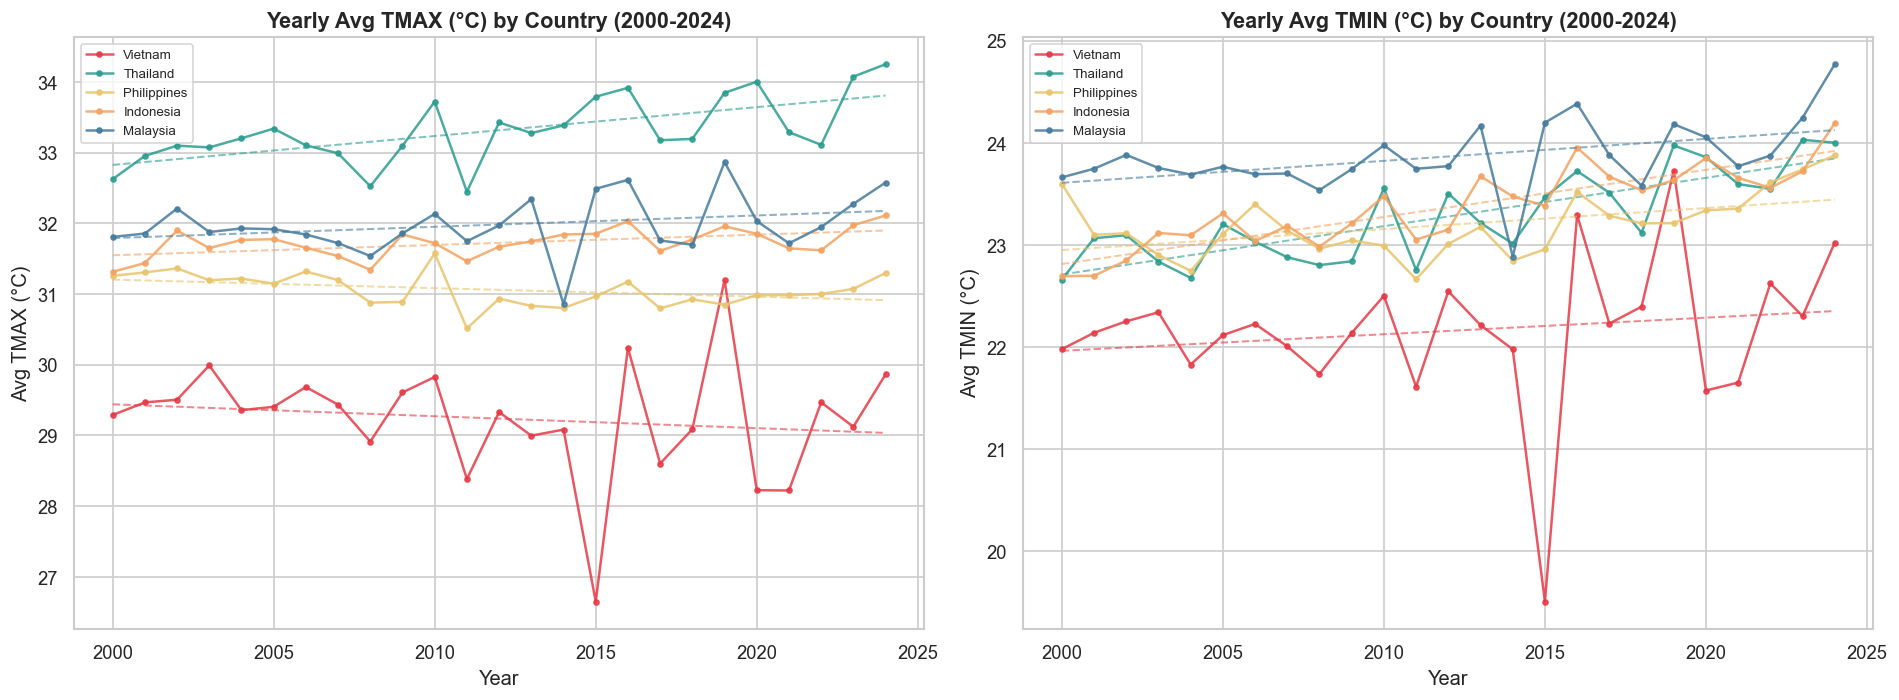


Warming rates (degrees C per decade) - linear regression on yearly avg TMAX:
   Thailand       : +0.473 C/decade
   Indonesia      : +0.461 C/decade
   Malaysia       : +0.215 C/decade
   Philippines    : +0.206 C/decade
   Vietnam        : +0.162 C/decade


In [67]:
# 1b: Yearly avg TMAX/TMIN per country with linear trendlines (2000-2024)
from sklearn.linear_model import LinearRegression

COUNTRIES_MAIN = ['Vietnam', 'Thailand', 'Philippines', 'Indonesia', 'Malaysia']
COUNTRY_COLORS = {
    'Vietnam':     '#e63946',
    'Thailand':    '#2a9d8f',
    'Philippines': '#e9c46a',
    'Indonesia':   '#f4a261',
    'Malaysia':    '#457b9d',
    'Myanmar':     '#a8dadc',
    'Laos':        '#6d6875',
    'Brunei':      '#b5838d',
    'Singapore':   '#e76f51',
    'Cambodia':    '#264653',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, metric, label in zip(axes, ['avg_TMAX', 'avg_TMIN'], ['Avg TMAX (°C)', 'Avg TMIN (°C)']):
    warming_rates = {}
    for country in COUNTRIES_MAIN:
        sub = yearly_temp_pd[yearly_temp_pd['COUNTRY'] == country].dropna(subset=[metric])
        if len(sub) < 5:
            continue
        color = COUNTRY_COLORS.get(country, 'gray')
        ax.plot(sub['YEAR'], sub[metric], 'o-', color=color, linewidth=1.5,
                markersize=3, label=country, alpha=0.85)
        # Linear trendline
        X = sub['YEAR'].values.reshape(-1, 1)
        y = sub[metric].values
        lr = LinearRegression().fit(X, y)
        ax.plot(sub['YEAR'], lr.predict(X), '--', color=color, linewidth=1.2, alpha=0.6)
        rate_per_decade = lr.coef_[0] * 10
        warming_rates[country] = rate_per_decade

    ax.set_title(f'Yearly {label} by Country (2000-2024)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel(label)
    ax.legend(fontsize=8, loc='upper left')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_01_temp_trends.png', bbox_inches='tight')
plt.show()

print("\nWarming rates (degrees C per decade) - linear regression on yearly avg TMAX:")
for c, r in sorted(warming_rates.items(), key=lambda x: -x[1]):
    print(f"   {c:<15}: {r:+.3f} C/decade")

---
## Analysis 2: Precipitation Pattern Changes

Yearly total precipitation, rainy day count, and rainfall intensity per country. Also: monsoon vs dry season comparison.

In [68]:
# 2a: Yearly precipitation aggregation
df_prcp = df.filter(col('PRCP').isNotNull())

yearly_prcp = df_prcp.groupBy('COUNTRY', 'YEAR').agg(
    avg('PRCP').alias('avg_daily_prcp_mm'),
    spark_sum('PRCP').alias('total_prcp_mm'),
    count(when(col('PRCP') > 1.0, 1)).alias('rainy_days'),
    count('PRCP').alias('obs_with_prcp'),
    avg(when(col('PRCP') > 1.0, col('PRCP'))).alias('rain_intensity_mm'),
).orderBy('COUNTRY', 'YEAR')

yearly_prcp_pd = yearly_prcp.toPandas()
print(f"Yearly precipitation aggregation: {len(yearly_prcp_pd)} rows")
yearly_prcp_pd[yearly_prcp_pd['COUNTRY'] == 'Vietnam'].head()

Yearly precipitation aggregation: 213 rows


,COUNTRY,YEAR,avg_daily_prcp_mm,total_prcp_mm,rainy_days,obs_with_prcp,rain_intensity_mm
188,Vietnam,2000,4.495838,11450.9,600,2547,18.836333
189,Vietnam,2001,3.910434,10081.1,608,2578,16.345230
190,Vietnam,2002,3.646759,9959.3,613,2731,16.034747
191,Vietnam,2003,3.565440,10079.5,590,2827,16.895085
192,Vietnam,2004,3.014415,8343.9,544,2768,15.103676


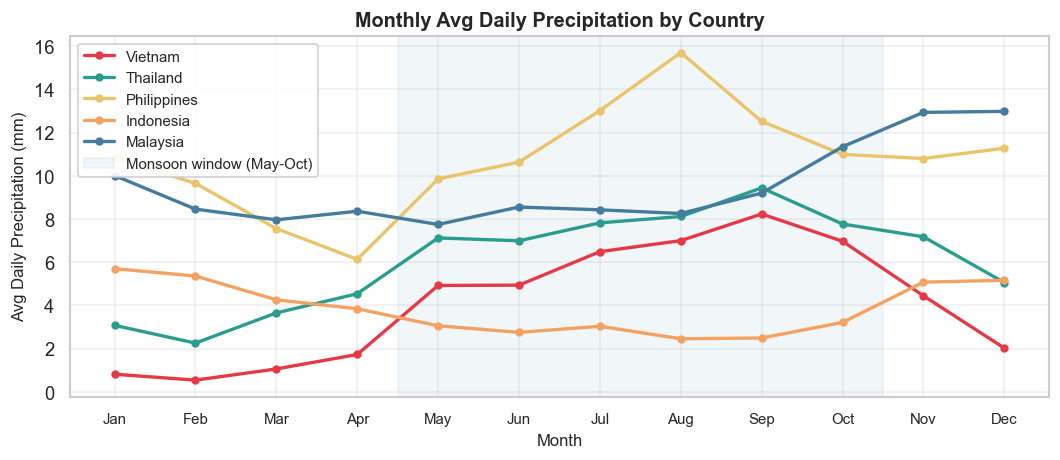

Monsoon seasonality chart saved


In [69]:
# 2c: Monthly avg precipitation per country (monsoon vs dry season)
monthly_prcp = df_prcp.filter(col('COUNTRY').isin(COUNTRIES_MAIN)) \
    .groupBy('COUNTRY', 'MONTH').agg(
        avg('PRCP').alias('avg_prcp_mm'),
        count(when(col('PRCP') > 1.0, 1)).alias('rainy_day_count'),
    ).toPandas()

MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(9, 4))

for country in COUNTRIES_MAIN:
    sub = monthly_prcp[monthly_prcp['COUNTRY'] == country].sort_values('MONTH')
    ax.plot(sub['MONTH'], sub['avg_prcp_mm'], 'o-', color=COUNTRY_COLORS[country],
            linewidth=2, markersize=4, label=country)

# Shade monsoon months (May-Oct)
ax.axvspan(4.5, 10.5, alpha=0.07, color='steelblue', label='Monsoon window (May-Oct)')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS, fontsize=9)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Avg Daily Precipitation (mm)', fontsize=10)
ax.set_title('Monthly Avg Daily Precipitation by Country', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_02_monsoon_seasonality.png', bbox_inches='tight')
plt.show()
print("Monsoon seasonality chart saved")

---
## Analysis 3: Seasonality Heatmaps

Month × Year heatmaps showing how temperature and precipitation seasonality has shifted over 25 years. Focus on Vietnam with a regional comparison panel.

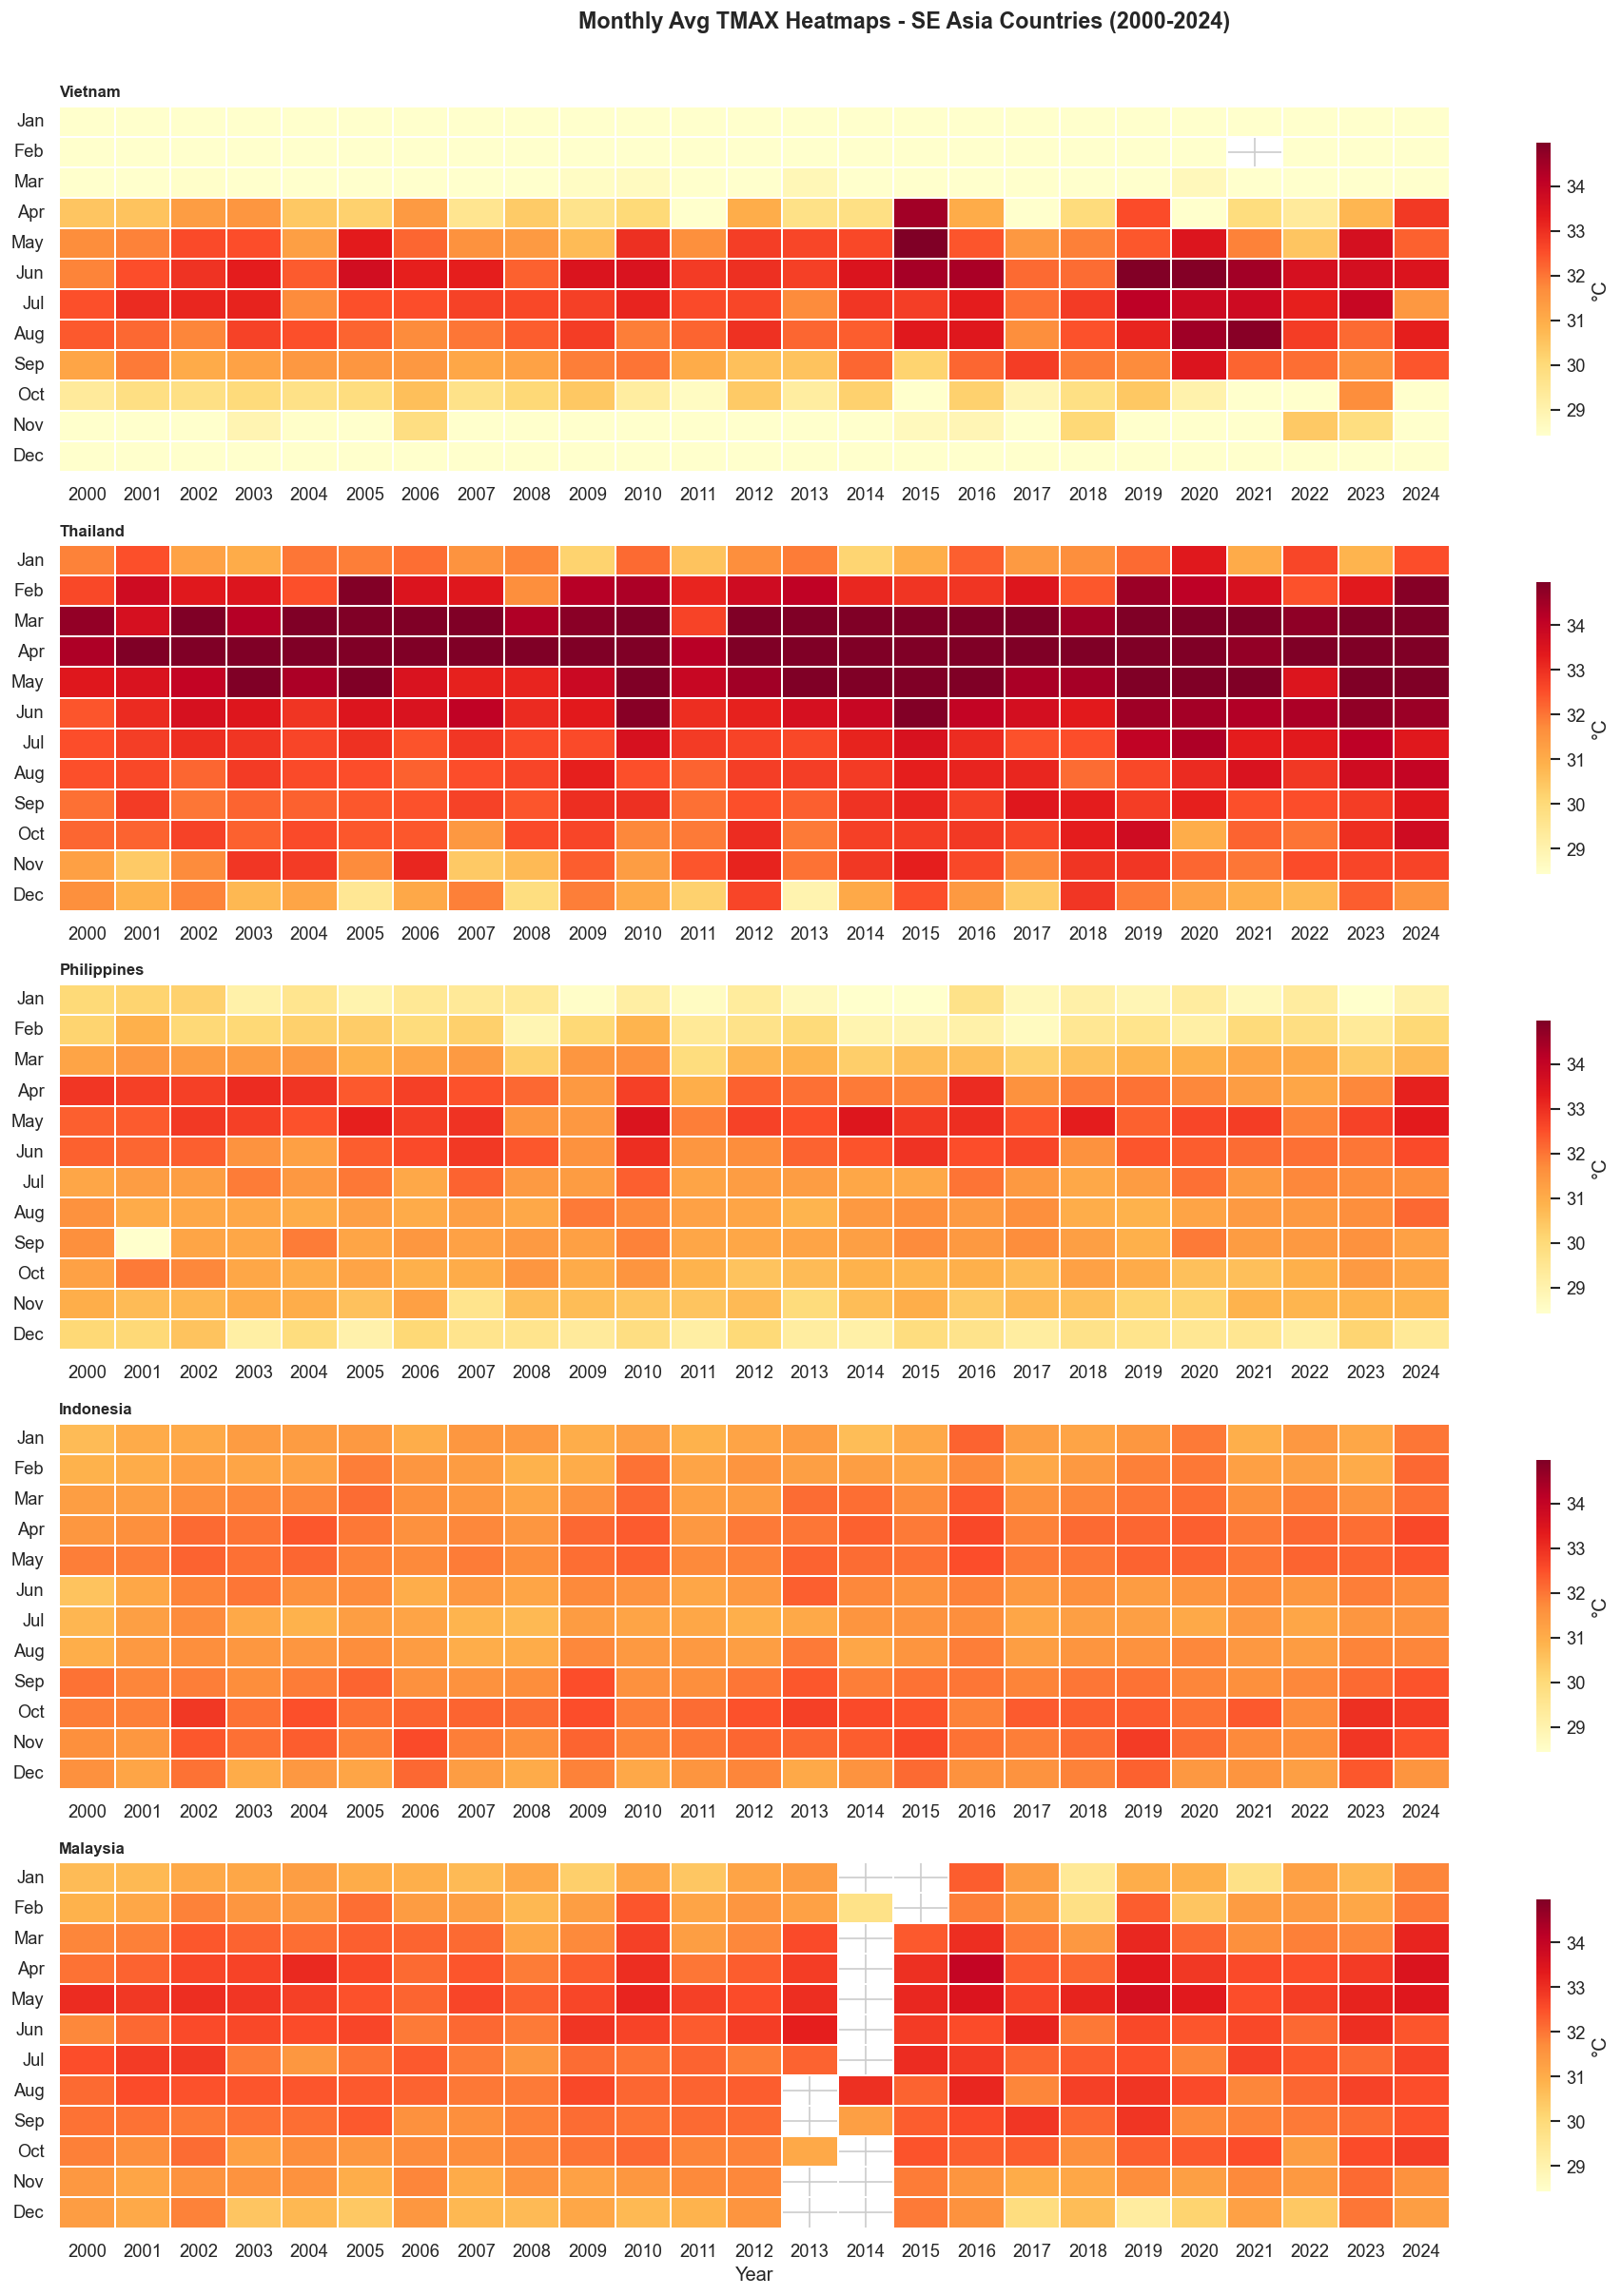

Multi-country heatmap saved


In [70]:
# 3c: Multi-country TMAX heatmap (small multiples)
monthly_yr_temp = df.groupBy('COUNTRY', 'MONTH', 'YEAR').agg(
    avg('TMAX').alias('avg_TMAX'),
).toPandas()

fig, axes = plt.subplots(len(COUNTRIES_MAIN), 1, figsize=(16, 20))

for ax, country in zip(axes, COUNTRIES_MAIN):
    sub = monthly_yr_temp[monthly_yr_temp['COUNTRY'] == country] \
        .pivot(index='MONTH', columns='YEAR', values='avg_TMAX')
    sub.index = MONTH_LABELS
    sns.heatmap(
        sub, ax=ax, cmap='YlOrRd', linewidths=0.2, linecolor='white',
        cbar_kws={'label': '°C', 'shrink': 0.8}, annot=False,
        vmin=monthly_yr_temp['avg_TMAX'].quantile(0.05),
        vmax=monthly_yr_temp['avg_TMAX'].quantile(0.95),
    )
    ax.set_title(f'{country}', fontsize=10, fontweight='bold', loc='left')
    ax.set_xlabel('')
    ax.set_ylabel('')

axes[-1].set_xlabel('Year')
plt.suptitle('Monthly Avg TMAX Heatmaps - SE Asia Countries (2000-2024)',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_03_heatmap_tmax_all_countries.png', bbox_inches='tight')
plt.show()
print("Multi-country heatmap saved")

---
## Analysis 4: Station Coverage Analysis

Map all 218 SE Asian stations, show data availability over time, and discuss sampling bias.

In [71]:
# 4a: Station metadata summary
station_meta = df.groupBy('STATION_ID', 'COUNTRY', 'LATITUDE', 'LONGITUDE', 'NAME') \
    .agg(count('*').alias('count')) \
    .toPandas()

print(f"Total unique stations in processed data: {len(station_meta)}")
print(station_meta['COUNTRY'].value_counts().to_string())
station_meta.head()

Total unique stations in processed data: 218
COUNTRY
Indonesia      103
Thailand        45
Philippines     23
Vietnam         16
Malaysia        16
Laos             7
Myanmar          5
Cambodia         1
Brunei           1
Singapore        1


,STATION_ID,COUNTRY,LATITUDE,LONGITUDE,NAME,count
0,IDM00096249,Indonesia,-2.746,107.755,H AS HANANDJOEDDIN,5572
1,TH000048400,Thailand,15.800,100.167,NAKHON SAWAN,6976
2,IDM00097028,Indonesia,1.017,120.800,TOLI-TOLI/LALOS,4688
3,VMM00048826,Vietnam,20.800,106.633,PHU LIEN,4358
4,TH000048550,Thailand,9.467,100.050,KO SAMUI,6778


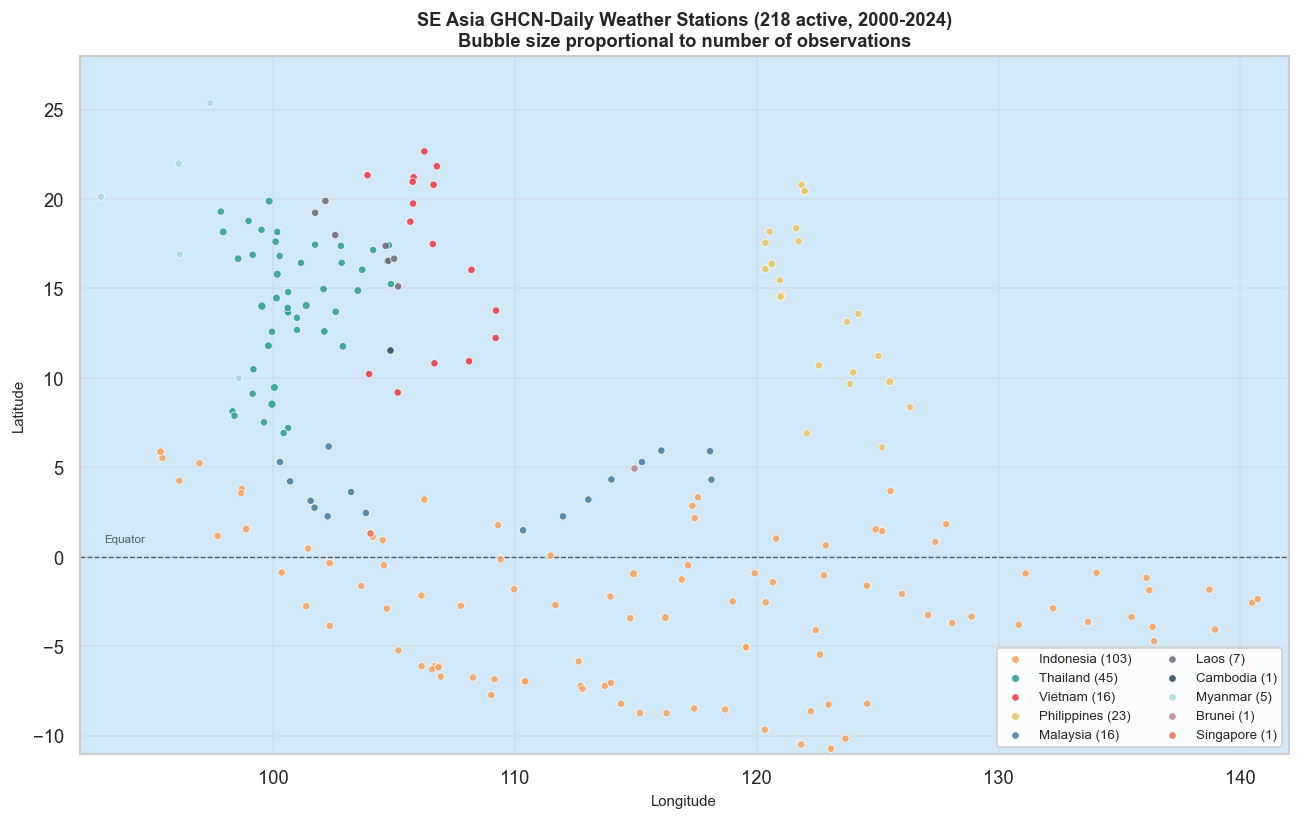

Station map saved


In [72]:
# 4b: Geospatial station map
fig, ax = plt.subplots(figsize=(11, 7))

ax.set_facecolor('#d0e8f7')
ax.set_xlim(92, 142)
ax.set_ylim(-11, 28)

# station_meta already includes obs count from cell 4a
for country in station_meta['COUNTRY'].unique():
    sub = station_meta[station_meta['COUNTRY'] == country]
    color = COUNTRY_COLORS.get(country, 'gray')
    sizes = (sub['count'].fillna(1000) / 300).clip(20, 250)
    ax.scatter(
        sub['LONGITUDE'], sub['LATITUDE'],
        c=color, s=sizes, alpha=0.85, edgecolors='white', linewidths=0.5,
        label=f"{country} ({len(sub)})",
        zorder=3,
    )

ax.set_title('SE Asia GHCN-Daily Weather Stations (218 active, 2000-2024)\n'
             'Bubble size proportional to number of observations', fontsize=11, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=9)
ax.set_ylabel('Latitude', fontsize=9)
ax.legend(fontsize=8, loc='lower right', framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.text(93, 0.8, 'Equator', fontsize=7, alpha=0.7)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_04_station_map.png', bbox_inches='tight')
plt.show()
print("Station map saved")

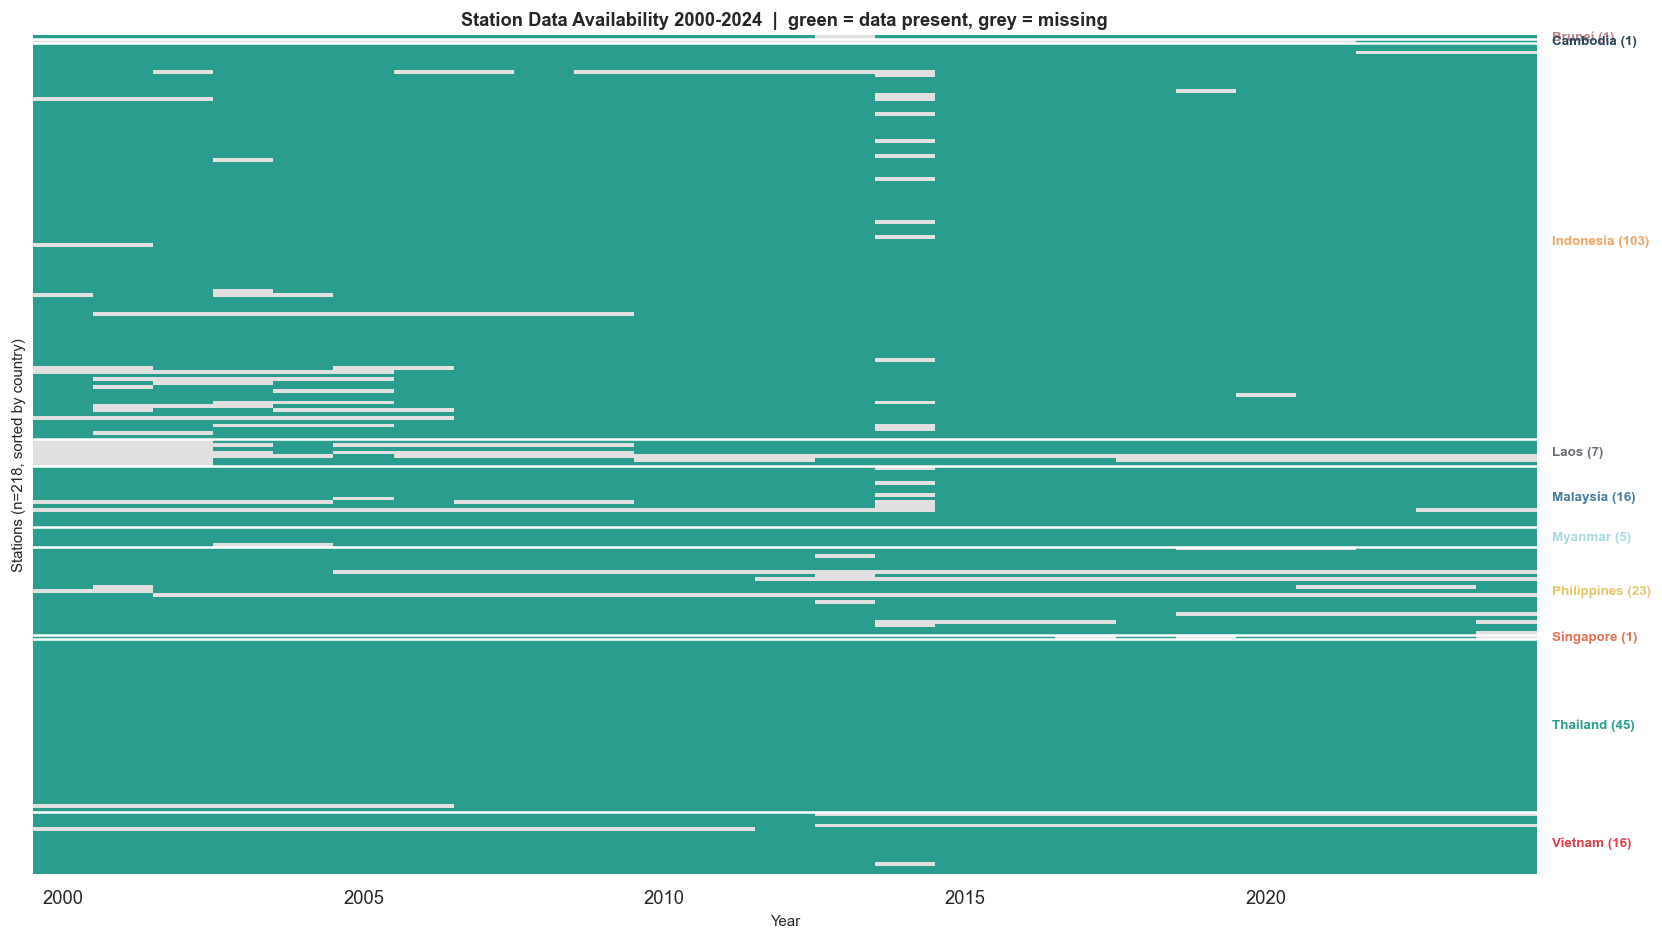

Data availability heatmap saved


In [73]:
# 4c: Data availability heatmap (station x year)
avail = df.groupBy('STATION_ID', 'YEAR').agg(
    count('*').alias('obs')
).join(
    df.select('STATION_ID', 'COUNTRY').distinct(), on='STATION_ID'
).toPandas()

avail_pivot = avail.pivot_table(
    index='STATION_ID', columns='YEAR', values='obs', fill_value=0
)

station_country_order = avail.groupby('STATION_ID')['COUNTRY'].first().reset_index()
station_country_order = station_country_order.sort_values(['COUNTRY', 'STATION_ID'])
avail_pivot = avail_pivot.loc[station_country_order['STATION_ID']]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    (avail_pivot > 0).astype(int),
    ax=ax, cmap=['#e0e0e0', '#2a9d8f'],
    cbar=False,
    linewidths=0, xticklabels=5, yticklabels=False,
)
ax.set_title('Station Data Availability 2000-2024  |  green = data present, grey = missing',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Year', fontsize=9)
ax.set_ylabel(f'Stations (n={len(avail_pivot)}, sorted by country)', fontsize=9)

# Country band labels on right with divider lines
y_pos = 0
for country in station_country_order['COUNTRY'].unique():
    n = (station_country_order['COUNTRY'] == country).sum()
    ax.annotate(f"{country} ({n})",
                xy=(1.01, 1 - (y_pos + n / 2) / len(avail_pivot)),
                xycoords='axes fraction', fontsize=8, va='center',
                color=COUNTRY_COLORS.get(country, 'black'), fontweight='bold')
    # Divider line between countries
    if y_pos > 0:
        ax.axhline(y=y_pos, color='white', linewidth=1.5, zorder=5)
    y_pos += n

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_05_data_availability.png', bbox_inches='tight')
plt.show()
print("Data availability heatmap saved")

---
## Analysis 5: Vietnam Focus — Detailed Country Analysis

Deep dive into Vietnam to address RQ4 (Vietnam vs neighbours) and prepare context for the report's Findings section.

In [74]:
# 5a: Vietnam warming rate vs neighbours
from scipy import stats

print("WARMING RATE ANALYSIS - Linear regression on yearly avg TMAX")

results = []
for country in COUNTRIES_MAIN:
    sub = yearly_temp_pd[yearly_temp_pd['COUNTRY'] == country].dropna(subset=['avg_TMAX'])
    if len(sub) < 10:
        continue
    X = sub['YEAR'].values
    y = sub['avg_TMAX'].values
    slope, intercept, r, p, se = stats.linregress(X, y)
    results.append({
        'Country': country,
        'Warming_rate_per_decade': slope * 10,
        'R2': r**2,
        'p_value': p,
        'Significant': 'yes' if p < 0.05 else 'no',
    })

results_df = pd.DataFrame(results).sort_values('Warming_rate_per_decade', ascending=False)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

WARMING RATE ANALYSIS - Linear regression on yearly avg TMAX
    Country  Warming_rate_per_decade     R2  p_value Significant
   Thailand                   0.4086 0.4051   0.0006         yes
   Malaysia                   0.1603 0.0840   0.1599          no
  Indonesia                   0.1458 0.2760   0.0070         yes
Philippines                  -0.1210 0.1451   0.0603          no
    Vietnam                  -0.1684 0.0219   0.4805          no


C:\Users\vubao\AppData\Local\Temp\ipykernel_25052\1445934368.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', vn_stations['STATION_ID'].nunique())


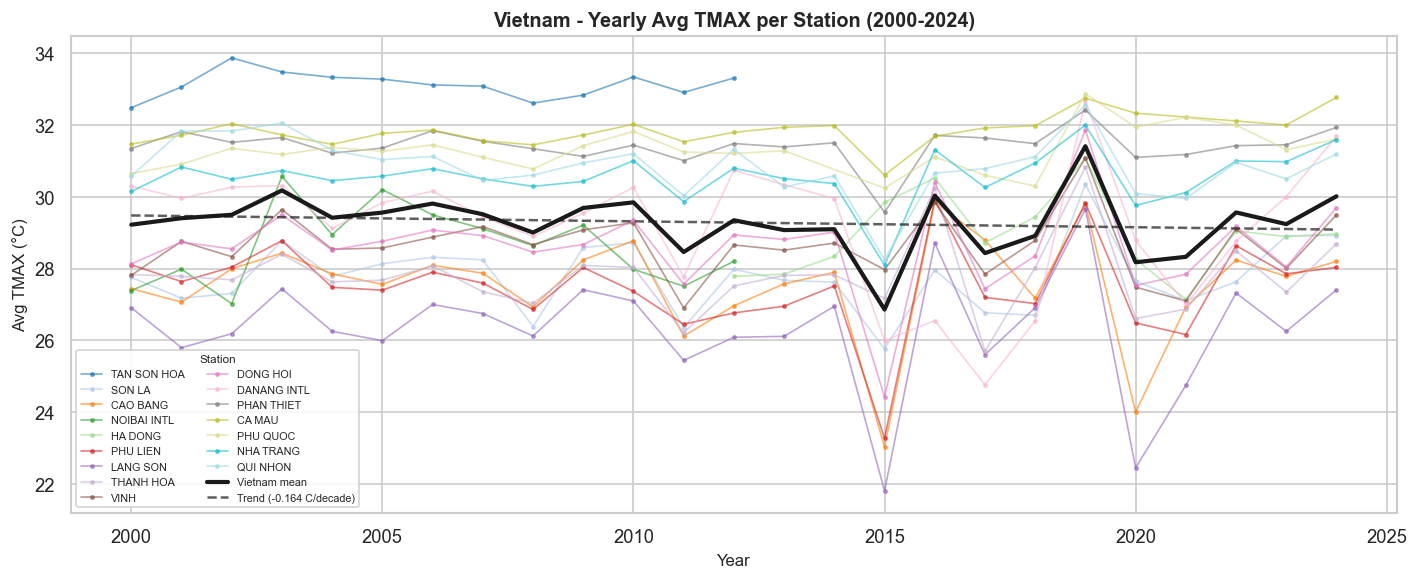

Vietnam station trends saved


In [75]:
# 5b: Vietnam station-level TMAX timeseries
vn_stations = df.filter(col('COUNTRY') == 'Vietnam') \
    .groupBy('STATION_ID', 'NAME', 'YEAR').agg(avg('TMAX').alias('avg_TMAX')) \
    .toPandas()

fig, ax = plt.subplots(figsize=(12, 5))

cmap = plt.cm.get_cmap('tab20', vn_stations['STATION_ID'].nunique())
station_ids = sorted(vn_stations['STATION_ID'].unique())

for i, sid in enumerate(station_ids):
    grp = vn_stations[vn_stations['STATION_ID'] == sid].sort_values('YEAR')
    name = grp['NAME'].iloc[0]
    ax.plot(grp['YEAR'], grp['avg_TMAX'], 'o-', color=cmap(i),
            alpha=0.6, linewidth=1, markersize=2, label=name)

vn_mean = vn_stations.groupby('YEAR')['avg_TMAX'].mean().reset_index()
ax.plot(vn_mean['YEAR'], vn_mean['avg_TMAX'], 'k-', linewidth=2.5,
        label='Vietnam mean', zorder=5)

X = vn_mean['YEAR'].values.reshape(-1, 1)
lr = LinearRegression().fit(X, vn_mean['avg_TMAX'].values)
ax.plot(vn_mean['YEAR'], lr.predict(X), 'k--', linewidth=1.5, alpha=0.7,
        label=f'Trend ({lr.coef_[0]*10:+.3f} C/decade)')

ax.set_title('Vietnam - Yearly Avg TMAX per Station (2000-2024)', fontsize=12, fontweight='bold')
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Avg TMAX (°C)', fontsize=10)
ax.legend(fontsize=6.5, loc='lower left', ncol=2, framealpha=0.85,
          title='Station', title_fontsize=7)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_06_vietnam_station_trends.png', bbox_inches='tight')
plt.show()
print("Vietnam station trends saved")

In [76]:
# EDA summary
print("EDA COMPLETE - Output files saved to ../output/")

import glob
charts = sorted(glob.glob(f'{OUTPUT_DIR}/eda_*.png'))
for c in charts:
    print(f"  {os.path.basename(c)}")

print(f"\nTotal charts produced: {len(charts)}")

EDA COMPLETE - Output files saved to ../output/
  eda_01_temp_trends.png
  eda_02_monsoon_seasonality.png
  eda_03_heatmap_tmax_all_countries.png
  eda_04_station_map.png
  eda_05_data_availability.png
  eda_06_vietnam_station_trends.png

Total charts produced: 6
